# Experimento 3: Validación Cruzada Espacial (K-Fold) - Análisis de Ablandaciones

Este notebook implementa validación cruzada espacial (K-Fold) para evaluar la robustez y generalización del modelo VAE + SOM con k=3 clusters, siguiendo los resultados óptimos del Experimento 2.

**Objetivo Principal:**
Evaluar la estabilidad territorial del modelo mediante:
1. División espacial en 5 folds (regiones geográficas del Valle de Aconcagua)
2. Cálculo de métricas de clustering interno por fold
3. Evaluación de estabilidad BASE → T585 por fold
4. Análisis de consistencia del IRT entre regiones
5. Identificación de zonas con comportamiento anómalo o inestable

**Configuración Fija (del Experimento 2):**
- Modelo: VAE (mejor representación latente)
- Método de clustering: SOM (mejor estabilidad espacial)
- Número de clusters: k = 3 (balance óptimo calidad/estabilidad)

**Metodología por Fold:**
Para cada fold regional (train 80%, test 20%):
1. Clustering interno en BASE (train):
   - Silhouette Score
   - Calinski-Harabasz Index
   - Davies-Bouldin Index
   - Dunn Index
   
2. Estabilidad BASE → T585 (train):
   - ARI_T585 (Adjusted Rand Index)
   - Avg_Jaccard_T585 (promedio de Jaccard por cluster)
   - Avg_Drift_T585 (desplazamiento latente medio)
   - Avg_Stability_T585 (estabilidad de pertenencia)
   
3. Índice de Resiliencia Territorial (train):
   - IRT_Mean (media del IRT)
   - IRT_Std (desviación estándar)
   - IRT_CV (coeficiente de variación)
   - IRT_IQR (rango intercuartílico)
   - Distribución espacial del IRT

4. Validación en fold test:
   - Coherencia espacial
   - Consistencia de métricas
   - Análisis de outliers regionales

**Análisis Final:**
- Media y desviación estándar de métricas entre folds
- Gráficos de variabilidad y consistencia
- Identificación de regiones problemáticas
- Evaluación de generalización del modelo
- Robustez territorial del IRT

## 1. Imports y configuración

In [1]:
import os
import sys
import pickle
import glob
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold
from scipy.stats import percentileofscore, gaussian_kde
from scipy.special import softmax
import warnings
warnings.filterwarnings('ignore')

BASE_DIR = "/home/aninotna/magister/tesis/justh2_pipeline"
if BASE_DIR not in sys.path:
    sys.path.insert(0, BASE_DIR)

DATA_DIR = os.path.join(BASE_DIR, "data")
PLOTS_DIR = os.path.join(BASE_DIR, "plots", "clustering_k_fold_validation")
os.makedirs(PLOTS_DIR, exist_ok=True)

# Importar librerías modulares
from scripts.idroverdi_autoencoder_3.utils.clustering import cluster_and_measure_resilience, get_cluster_summary
from scripts.idroverdi_autoencoder_3.resilience_lib import (
    compute_IRCT_from_clustering_results,
    aggregate_IRCT_by_cluster,
    compute_IRCT_pixel_wise
)

# Configuración del experimento (basado en resultados del Experimento 2)
MODEL_KEY = "VAE"  # Mejor modelo según Experimento 2
CLUSTERING_METHOD = "SOM"  # Mejor método según Experimento 2
K_CLUSTERS = 3  # Valor óptimo según análisis de sensibilidad
N_FOLDS = 5  # Validación cruzada espacial
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

# Configuración de estilo de gráficos
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

print(f"Configuracion del Experimento 3: Validacion Cruzada Espacial")
print(f"Modelo: {MODEL_KEY}")
print(f"Metodo de clustering: {CLUSTERING_METHOD}")
print(f"Numero de clusters: {K_CLUSTERS}")
print(f"Numero de folds: {N_FOLDS}")
print(f"Directorio de plots: {PLOTS_DIR}")
print(f"Seed: {SEED}")

Configuracion del Experimento 3: Validacion Cruzada Espacial
Modelo: VAE
Metodo de clustering: SOM
Numero de clusters: 3
Numero de folds: 5
Directorio de plots: /home/aninotna/magister/tesis/justh2_pipeline/plots/clustering_k_fold_validation
Seed: 42


## 2. Definición de arquitecturas AE y VAE

In [2]:
class AE(nn.Module):
    def __init__(self, input_dim, latent_dim=8, p_drop=0.1):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(p_drop),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(p_drop),
            nn.Linear(64, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(64, 128),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(128, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z


class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=12, p_drop=0.05):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(p_drop),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.1, inplace=True),
        )
        self.mu = nn.Linear(64, latent_dim)
        self.logvar = nn.Linear(64, latent_dim)

        self.dec = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(64, 128),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(128, 256),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Linear(256, input_dim),
        )
    
    def encode(self, x):
        h = self.enc(x)
        return self.mu(h), self.logvar(h)
    
    def reparam(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        x_hat = self.dec(z)
        return x_hat, mu, logvar

print("Arquitecturas AE y VAE definidas")

Arquitecturas AE y VAE definidas


## 3. Carga de datos del Experimento 1

In [3]:
print("CARGANDO DATOS DESDE EXPERIMENTO 1")
print()

# Buscar el archivo más reciente automáticamente
import glob
trained_dir = os.path.join(DATA_DIR, "autoencoder_trained_v2")
pattern = os.path.join(trained_dir, "experiment1_clustering_*.pkl")
available_files = glob.glob(pattern)

if not available_files:
    raise FileNotFoundError(f"No se encontraron archivos en: {pattern}")

# Ordenar por fecha de modificación (más reciente primero)
export_path = max(available_files, key=os.path.getmtime)

print(f"Archivo más reciente encontrado: {os.path.basename(export_path)}")
print(f"Ruta completa: {export_path}")
print()

if os.path.exists(export_path):
    print(f"Cargando datos...")
    print()
    
    with open(export_path, "rb") as f:
        exp1_data = pickle.load(f)
    
    # 1. Cargar modelos PyTorch
    print("1. Cargando modelos PyTorch...")
    models_path = exp1_data["models_path"]
    model_dims = exp1_data["model_dims"]
    
    MODELS = {}
    for model_key, model_file in models_path.items():
        dims = model_dims[model_key]
        
        if "AE" in model_key and "VAE" not in model_key:
            model = AE(
                input_dim=dims["input_dim"],
                latent_dim=dims["latent_dim"]
            )
        else:
            model = VAE(
                input_dim=dims["input_dim"],
                latent_dim=dims["latent_dim"]
            )
        
        model.load_state_dict(torch.load(model_file))
        model.eval()
        MODELS[model_key] = model
        print(f"  ✓ {model_key} (input={dims['input_dim']}, latent={dims['latent_dim']})")
    print()
    
    # 2. Extraer objetos del pickle
    print("2. Cargando datos adicionales...")
    LATENTS = exp1_data["LATENTS"]
    LATENT_LOGVARS = exp1_data.get("LATENT_LOGVARS", None)
    
    MODEL_ORDER = exp1_data["MODEL_ORDER"]
    LATENT_DIM_AE = exp1_data["LATENT_DIM_AE"]
    LATENT_DIM_VAE = exp1_data["LATENT_DIM_VAE"]
    N_PER_SCENARIO = exp1_data["N_PER_SCENARIO"]
    
    X_BASE = exp1_data["X_BASE"]
    X245_orig = exp1_data["X245_orig"]
    X370_orig = exp1_data["X370_orig"]
    X585_orig = exp1_data["X585_orig"]
    
    X245_norm = exp1_data.get("X245_norm", None)
    X370_norm = exp1_data.get("X370_norm", None)
    X585_norm = exp1_data.get("X585_norm", None)
    
    feature_names = exp1_data["feature_names"]
    coords_df = exp1_data["coords_df"]
    
    file_size_mb = os.path.getsize(export_path) / (1024 * 1024)
    
    print(f"  ✓ Datos cargados ({file_size_mb:.2f} MB)")
    print()
    
    print("Objetos cargados:")
    print(f"  • MODELS: {len(MODELS)} modelos ({', '.join(MODELS.keys())})")
    print(f"  • LATENTS: {len(LATENTS)} conjuntos de embeddings")
    print(f"  • N_PER_SCENARIO: {N_PER_SCENARIO} puntos espaciales")
    print(f"  • feature_names: {len(feature_names)} variables")
    print(f"  • coords_df: {coords_df.shape[0]} píxeles")
    print()
    
else:
    raise FileNotFoundError(f"No se encontró {export_path}")

CARGANDO DATOS DESDE EXPERIMENTO 1

Archivo más reciente encontrado: experiment1_clustering_20251209_001834.pkl
Ruta completa: /home/aninotna/magister/tesis/justh2_pipeline/data/autoencoder_trained_v2/experiment1_clustering_20251209_001834.pkl

Cargando datos...

1. Cargando modelos PyTorch...
  ✓ AE (input=29, latent=8)
  ✓ VAE (input=29, latent=8)

2. Cargando datos adicionales...
  ✓ Datos cargados (2.00 MB)

Objetos cargados:
  • MODELS: 2 modelos (AE, VAE)
  • LATENTS: 2 conjuntos de embeddings
  • N_PER_SCENARIO: 661 puntos espaciales
  • feature_names: 47 variables
  • coords_df: 661 píxeles



In [4]:
print(f"Total de features: {len(feature_names)}\n")
print("="*80)
print("Índice | Nombre de Variable")
print("="*80)
for i, name in enumerate(feature_names):
    print(f"{i:3d}    | {name}")
print("="*80)

Total de features: 47

Índice | Nombre de Variable
  0    | calliope_cf_mean
  1    | calliope_cap_electrolyzer_mw
  2    | topo_slope
  3    | topo_elevation
  4    | landuse_suitable_pv
  5    | landuse_restricted
  6    | landuse_agriculture
  7    | landuse_urban_infra
  8    | landuse_water_glacier
  9    | conflict_density
 10    | conflict_proximity
 11    | calliope_h2_prod_ton_decadal_mean_2020
 12    | calliope_h2_prod_ton_decadal_mean_2050
 13    | calliope_h2_prod_ton_decadal_mean_2080
 14    | climate_tmax_mean_decadal_mean_2020
 15    | climate_tmax_mean_decadal_mean_2050
 16    | climate_tmax_mean_decadal_mean_2080
 17    | climate_tmin_mean_decadal_mean_2020
 18    | climate_tmin_mean_decadal_mean_2050
 19    | climate_tmin_mean_decadal_mean_2080
 20    | climate_prcptot_decadal_mean_2020
 21    | climate_prcptot_decadal_mean_2050
 22    | climate_prcptot_decadal_mean_2080
 23    | climate_r10mm_decadal_mean_2020
 24    | climate_r10mm_decadal_mean_2050
 25    | climate

## 4 Definición de Grupos de Ablación

Basado en las variables disponibles, definimos grupos temáticos coherentes:

**Grupos Climáticos:**
- **Temperatura**: tmax_mean, tmin_mean (ambos períodos + variabilidad)
- **Precipitación Total**: prcptot, r10mm (total y días >10mm)
- **Precipitación Extrema**: rx1day, rx5day (máximos 1 y 5 días)
- **Sequía**: cdd (días secos consecutivos)
- **Intensidad**: sdii (intensidad diaria de precipitación)

**Grupos No-Climáticos:**
- **Producción H₂**: calliope_h2_prod (medias y variabilidad)
- **Calliope Solar**: cf_mean, cap_electrolyzer
- **Topografía**: slope, elevation
- **Uso de Suelo**: suitable_pv, restricted, agriculture, urban, water
- **Conflictos**: density, proximity

In [5]:
def find_features_by_pattern(feature_names, patterns):
    """Encuentra features que contengan cualquiera de los patrones dados."""
    found_indices = []
    found_names = []
    for i, name in enumerate(feature_names):
        if any(pattern in name for pattern in patterns):
            found_indices.append(i)
            found_names.append(name)
    return found_indices, found_names

# IMPORTANTE: Usar solo las features que el modelo realmente usa
input_dim_model = model_dims["VAE"]["input_dim"]  # Usar VAE como referencia
feature_names_model = feature_names[:input_dim_model]

print(f"AJUSTANDO GRUPOS DE ABLACIÓN A LAS {input_dim_model} FEATURES DEL MODELO")
print(f"(Features totales disponibles: {len(feature_names)})")
print()

# Definición de grupos de ablación con nombres exactos (29 features del modelo)
ABLATION_GROUPS = {
    # Grupos climáticos (foco principal de la tesis)
    'Temperatura': {
        'patterns': ['climate_tmax_mean_decadal_mean', 'climate_tmin_mean_decadal_mean'],
        'description': 'Variables de temperatura máxima y mínima (3 décadas)',
        'expected_count': 6
    },
    'Precipitación_Total': {
        'patterns': ['climate_prcptot_decadal_mean', 'climate_r10mm_decadal_mean'],
        'description': 'Precipitación total y frecuencia de días con >10mm (3 décadas)',
        'expected_count': 6
    },
    'Precipitación_Extrema': {
        'patterns': ['climate_rx1day_decadal_mean'],
        'description': 'Precipitación máxima en 1 día consecutivo (3 décadas)',
        'expected_count': 3
    },
    
    # Grupos no-climáticos
    'Producción_H2': {
        'patterns': ['calliope_h2_prod_ton_decadal_mean'],
        'description': 'Producción de hidrógeno modelada por Calliope (3 décadas)',
        'expected_count': 3
    },
    'Capacidad_Solar': {
        'patterns': ['calliope_cf_mean', 'calliope_cap_electrolyzer_mw'],
        'description': 'Capacidad solar y electrolizadores del modelo energético',
        'expected_count': 2
    },
    'Topografía': {
        'patterns': ['topo_slope', 'topo_elevation'],
        'description': 'Pendiente y elevación del terreno',
        'expected_count': 2
    },
    'Uso_Suelo': {
        'patterns': ['landuse_'],
        'description': 'Aptitud para PV, restricciones, agricultura, urbano, agua/glaciares',
        'expected_count': 5
    },
    'Conflictos': {
        'patterns': ['conflict_'],
        'description': 'Densidad y proximidad a conflictos socioambientales',
        'expected_count': 2
    }
}

# Identificar features por grupo
print("Grupos de ablación definidos:")
print()
for group_name, group_info in ABLATION_GROUPS.items():
    indices, names = find_features_by_pattern(feature_names_model, group_info['patterns'])
    group_info['indices'] = indices
    group_info['names'] = names
    
    expected = group_info['expected_count']
    found = len(names)
    status = "OK" if found == expected else f"ADVERTENCIA: esperadas {expected}, encontradas {found}"
    
    print(f"{group_name} ({found} features) - {status}")
    print(f"  {group_info['description']}")
    if names:
        for name in names:
            print(f"    - {name}")
    print()

# Verificar cobertura total
all_ablation_indices = set()
for group_info in ABLATION_GROUPS.values():
    all_ablation_indices.update(group_info['indices'])

print()
print(f"Total de features en grupos: {len(all_ablation_indices)}/{len(feature_names_model)}")
print(f"Features no asignadas: {len(feature_names_model) - len(all_ablation_indices)}")

# Mostrar features no asignadas
missing_indices = set(range(len(feature_names_model))) - all_ablation_indices
if missing_indices:
    print("\nFeatures no asignadas a ningún grupo:")
    for idx in sorted(missing_indices):
        print(f"  {idx}: {feature_names_model[idx]}")

# Nota sobre features climáticas fuera del modelo
print("\n" + "="*80)
print("NOTA: VARIABLES CLIMÁTICAS NO USADAS EN EL MODELO ACTUAL")
print("="*80)
print("Las siguientes variables están disponibles en el dataset pero NO")
print("se incluyeron en el modelo actual (índices >= 29):")
print()
print("  • climate_rx5day_* (índices 29-31): Precipitación máxima en 5 días")
print("  • climate_cdd_* (índices 32-34): Días secos consecutivos (SEQUÍA)")
print("  • climate_sdii_* (índices 35-37): Intensidad diaria de precipitación")
print("  • *_std_T: Variabilidad temporal de variables climáticas")
print()
print("Estas variables representan extremos y variabilidad climática relevante")
print("y se proponen como extensión futura para nuevos experimentos.")
print("="*80)

AJUSTANDO GRUPOS DE ABLACIÓN A LAS 29 FEATURES DEL MODELO
(Features totales disponibles: 47)

Grupos de ablación definidos:

Temperatura (6 features) - OK
  Variables de temperatura máxima y mínima (3 décadas)
    - climate_tmax_mean_decadal_mean_2020
    - climate_tmax_mean_decadal_mean_2050
    - climate_tmax_mean_decadal_mean_2080
    - climate_tmin_mean_decadal_mean_2020
    - climate_tmin_mean_decadal_mean_2050
    - climate_tmin_mean_decadal_mean_2080

Precipitación_Total (6 features) - OK
  Precipitación total y frecuencia de días con >10mm (3 décadas)
    - climate_prcptot_decadal_mean_2020
    - climate_prcptot_decadal_mean_2050
    - climate_prcptot_decadal_mean_2080
    - climate_r10mm_decadal_mean_2020
    - climate_r10mm_decadal_mean_2050
    - climate_r10mm_decadal_mean_2080

Precipitación_Extrema (3 features) - OK
  Precipitación máxima en 1 día consecutivo (3 décadas)
    - climate_rx1day_decadal_mean_2020
    - climate_rx1day_decadal_mean_2050
    - climate_rx1day_deca

## 5. Entrenamiento de Modelos Ablados

Para cada grupo de ablación:
1. Crear un dataset excluyendo las features del grupo
2. Re-entrenar VAE con la misma arquitectura (ajustando input_dim)
3. Extraer representaciones latentes para BASE y T585
4. Aplicar clustering SOM con k=3
5. Calcular métricas de clustering y estabilidad
6. Calcular IRT y sus estadísticas
7. Comparar vs modelo completo

In [6]:
# Función para entrenar un VAE ablado
def train_ablated_vae(X_train, latent_dim=12, p_drop=0.05, epochs=100, lr=1e-3, batch_size=128):
    """
    Entrena un VAE con un subset de features (modelo ablado).
    
    Returns:
        model: VAE entrenado
        history: diccionario con pérdidas por época
    """
    input_dim = X_train.shape[1]
    
    # Crear modelo
    model = VAE(input_dim=input_dim, latent_dim=latent_dim, p_drop=p_drop)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # Convertir a tensor
    X_tensor = torch.FloatTensor(X_train)
    dataset = torch.utils.data.TensorDataset(X_tensor)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    # Training loop
    model.train()
    history = {'total_loss': [], 'recon_loss': [], 'kl_loss': []}
    
    for epoch in range(epochs):
        total_loss_epoch = 0
        recon_loss_epoch = 0
        kl_loss_epoch = 0
        n_batches = 0
        
        for (batch_x,) in loader:
            optimizer.zero_grad()
            
            # Forward pass
            x_recon, mu, logvar = model(batch_x)
            
            # Reconstruction loss (MSE)
            recon_loss = nn.functional.mse_loss(x_recon, batch_x, reduction='mean')
            
            # KL divergence
            kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / batch_x.size(0)
            
            # Total loss (beta-VAE with beta=0.5)
            loss = recon_loss + 0.5 * kl_loss
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            total_loss_epoch += loss.item()
            recon_loss_epoch += recon_loss.item()
            kl_loss_epoch += kl_loss.item()
            n_batches += 1
        
        # Guardar historia
        history['total_loss'].append(total_loss_epoch / n_batches)
        history['recon_loss'].append(recon_loss_epoch / n_batches)
        history['kl_loss'].append(kl_loss_epoch / n_batches)
        
        if (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch+1}/{epochs} - Loss: {history['total_loss'][-1]:.4f} "
                  f"(Recon: {history['recon_loss'][-1]:.4f}, KL: {history['kl_loss'][-1]:.4f})")
    
    model.eval()
    return model, history

print("Función de entrenamiento de VAE ablado definida")

Función de entrenamiento de VAE ablado definida


In [7]:
# Función para obtener embeddings latentes de un VAE
def get_vae_embeddings(model, X):
    """Extrae embeddings latentes (mu) de un VAE."""
    model.eval()
    with torch.no_grad():
        X_tensor = torch.FloatTensor(X)
        mu, logvar = model.encode(X_tensor)
        return mu.numpy()

# Función para calcular métricas de clustering
def compute_clustering_metrics(Z, labels):
    """
    Calcula métricas internas de clustering.
    
    Returns:
        dict con Silhouette, Calinski, Davies_Bouldin, Dunn
    """
    from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
    from scipy.spatial.distance import pdist, squareform
    
    metrics = {}
    
    # Silhouette
    metrics['Silhouette'] = silhouette_score(Z, labels)
    
    # Calinski-Harabasz
    metrics['Calinski'] = calinski_harabasz_score(Z, labels)
    
    # Davies-Bouldin
    metrics['Davies_Bouldin'] = davies_bouldin_score(Z, labels)
    
    # Dunn Index
    # Distancias intra-cluster (máximo)
    max_intra = 0
    for k in np.unique(labels):
        mask_k = labels == k
        if np.sum(mask_k) > 1:
            dists_k = pdist(Z[mask_k])
            if len(dists_k) > 0:
                max_intra = max(max_intra, np.max(dists_k))
    
    # Distancias inter-cluster (mínimo)
    centroids = np.array([Z[labels == k].mean(axis=0) for k in np.unique(labels)])
    if len(centroids) > 1:
        min_inter = np.min(pdist(centroids))
        metrics['Dunn'] = min_inter / max_intra if max_intra > 0 else 0.0
    else:
        metrics['Dunn'] = 0.0
    
    return metrics

print("Funciones auxiliares para embeddings y métricas definidas")

Funciones auxiliares para embeddings y métricas definidas


In [8]:
# Función para calcular estabilidad BASE -> T585
def compute_stability_metrics(Z_base, labels_base, Z_585, labels_585):
    """
    Calcula métricas de estabilidad entre escenarios BASE y T585.
    
    Returns:
        dict con ARI_T585, Avg_Jaccard_T585, Avg_Drift_T585, Avg_Stability_T585
    """
    from sklearn.metrics import adjusted_rand_score
    from scipy.optimize import linear_sum_assignment
    
    metrics = {}
    
    # ARI (Adjusted Rand Index)
    metrics['ARI_T585'] = adjusted_rand_score(labels_base, labels_585)
    
    # Jaccard Index por cluster (con alineación óptima)
    k_values = np.unique(labels_base)
    n_clusters = len(k_values)
    
    # Matriz de confusión normalizada
    confusion = np.zeros((n_clusters, n_clusters))
    for i, k_base in enumerate(k_values):
        for j, k_585 in enumerate(k_values):
            intersection = np.sum((labels_base == k_base) & (labels_585 == k_585))
            union = np.sum((labels_base == k_base) | (labels_585 == k_585))
            confusion[i, j] = intersection / union if union > 0 else 0
    
    # Alineación óptima usando Hungarian algorithm
    row_ind, col_ind = linear_sum_assignment(-confusion)
    jaccard_scores = [confusion[i, j] for i, j in zip(row_ind, col_ind)]
    metrics['Avg_Jaccard_T585'] = np.mean(jaccard_scores)
    
    # Drift (desplazamiento en espacio latente)
    drift_per_pixel = np.linalg.norm(Z_585 - Z_base, axis=1)
    metrics['Avg_Drift_T585'] = np.mean(drift_per_pixel)
    
    # Stability (proporción de píxeles que mantienen su cluster)
    # Usar la alineación óptima
    label_map = {k_values[i]: k_values[j] for i, j in zip(row_ind, col_ind)}
    labels_585_aligned = np.array([label_map[l] for l in labels_585])
    metrics['Avg_Stability_T585'] = np.mean(labels_base == labels_585_aligned)
    
    return metrics

print("Función de métricas de estabilidad definida")

Función de métricas de estabilidad definida


In [9]:
# Función para calcular IRT simplificado
def compute_irct_indicators(vae_model, X_base, X_585, Z_base, Z_585, labels_base, centroids_base):
    """
    Calcula IRCT usando la biblioteca oficial resilience_lib.py
    
    Returns:
        dict con IRCT_Mean, IRCT_Std, IRCT_CV, IRCT_IQR, IRCT_Q10, IRCT_Q90, irct_values (escalado 0-100)
    """
    # Normalizar datos para compute_IRCT_pixel_wise (espera datos normalizados)
    from sklearn.preprocessing import StandardScaler
    scaler_base = StandardScaler()
    scaler_585 = StandardScaler()
    
    X_base_norm = scaler_base.fit_transform(X_base)
    X_585_norm = scaler_585.fit_transform(X_585)
    
    # Calcular IRCT usando biblioteca oficial
    irct_dict = compute_IRCT_pixel_wise(
        model=vae_model,
        X_base_orig=X_base,
        X_base_norm=X_base_norm,
        X_future_orig=X_585,
        X_future_norm=X_585_norm,
        z_base_scaled=Z_base,
        z_future_scaled=Z_585,
        centroids_base=centroids_base,
        labels_base=labels_base,
        h2_base=None,
        h2_future=None,
        weights={'w_a': 0.15, 'w_d': 0.30, 'w_c': 0.25, 'w_e': 0.20, 'w_h': 0.10},
        device='cpu'
    )
    
    # Extraer IRCT y escalar a [0, 100]
    irct_values = irct_dict['IRCT'] * 100
    
    # Estadísticas descriptivas
    metrics = {
        'IRT_Mean': np.mean(irct_values),
        'IRT_Std': np.std(irct_values),
        'IRT_CV': np.std(irct_values) / np.mean(irct_values) if np.mean(irct_values) > 0 else 0,
        'IRT_IQR': np.percentile(irct_values, 75) - np.percentile(irct_values, 25),
        'IRT_Q10': np.percentile(irct_values, 10),
        'IRT_Q90': np.percentile(irct_values, 90),
        'irt_values': irct_values
    }
    
    return metrics

print("Función de cálculo de IRT definida")

Función de cálculo de IRT definida


## 6. Pipeline de Ablación Completo

Ejecutar el pipeline completo:
1. Obtener métricas del modelo completo (baseline)
2. Para cada grupo de ablación:
   - Crear dataset ablado
   - Entrenar VAE
   - Extraer embeddings
   - Clustering SOM k=3
   - Calcular métricas
   - Comparar vs baseline

In [10]:
# IMPORTANTE: Ajustar datos de escenarios a las 29 features del modelo
print("Ajustando datos de escenarios a las features del modelo...")
print(f"Features del modelo: {input_dim_model}")
print(f"X_BASE shape original: {X_BASE.shape}")
print(f"X585_norm shape original: {X585_norm.shape}")
print(f"N_PER_SCENARIO: {N_PER_SCENARIO}")
print()

# CORREGIR: X_BASE tiene 3x los datos (BASE stacked 3 veces?)
# Tomar solo los primeros N_PER_SCENARIO píxeles
X_BASE_single = X_BASE[:N_PER_SCENARIO, :input_dim_model]
X_585_single = X585_norm[:N_PER_SCENARIO, :input_dim_model]
X_245_single = X245_norm[:N_PER_SCENARIO, :input_dim_model] if X245_norm is not None else None
X_370_single = X370_norm[:N_PER_SCENARIO, :input_dim_model] if X370_norm is not None else None

print(f"X_BASE_single shape corregido: {X_BASE_single.shape}")
print(f"X_585_single shape corregido: {X_585_single.shape}")
print()
print(f"Datos corregidos a {N_PER_SCENARIO} píxeles × {input_dim_model} features")
print()

Ajustando datos de escenarios a las features del modelo...
Features del modelo: 29
X_BASE shape original: (1983, 29)
X585_norm shape original: (661, 47)
N_PER_SCENARIO: 661

X_BASE_single shape corregido: (661, 29)
X_585_single shape corregido: (661, 29)

Datos corregidos a 661 píxeles × 29 features



In [11]:
# Importar SimpleSOM desde utils
from scripts.idroverdi_autoencoder_3.utils.clustering import SimpleSOM

print("PASO 1: Calcular métricas del modelo completo (BASELINE)")
print("="*80)
print()

# Usar el modelo VAE pre-entrenado
model_full = MODELS["VAE"]

# Extraer embeddings para BASE y T585 (usando datos corregidos)
print("Extrayendo embeddings del modelo completo...")
Z_base_full = get_vae_embeddings(model_full, X_BASE_single)
Z_585_full = get_vae_embeddings(model_full, X_585_single)

# Aplicar clustering SOM k=3
print(f"Aplicando clustering SOM con k={K_CLUSTERS}...")
som_full = SimpleSOM(x_dim=K_CLUSTERS, y_dim=1, input_len=Z_base_full.shape[1], random_state=SEED, n_iterations=1000)
som_full.fit(Z_base_full)

# Obtener labels como índices de cluster (0, 1, 2)
# SimpleSOM.predict devuelve array de shape (N,) con valores de SOM grid flattened
# Necesitamos convertir a coordenadas (x, y) y luego tomar solo x
labels_base_full_raw = som_full.predict(Z_base_full)
labels_585_full_raw = som_full.predict(Z_585_full)

print(f"  DEBUG: labels_base_full_raw.shape = {labels_base_full_raw.shape}")
print(f"  DEBUG: labels_585_full_raw.shape = {labels_585_full_raw.shape}")
print(f"  DEBUG: Z_base_full.shape[0] = {Z_base_full.shape[0]}")
print(f"  DEBUG: Z_585_full.shape[0] = {Z_585_full.shape[0]}")

# SimpleSOM.predict puede devolver más elementos de lo esperado
# Verificar y corregir cada array independientemente
if len(labels_base_full_raw) != Z_base_full.shape[0]:
    print(f"  ADVERTENCIA: labels_base tiene {len(labels_base_full_raw)} elementos, esperados {Z_base_full.shape[0]}")
    # Tomar solo los primeros N elementos (un label por píxel)
    labels_base_full = labels_base_full_raw[:Z_base_full.shape[0]]
else:
    labels_base_full = labels_base_full_raw

if len(labels_585_full_raw) != Z_585_full.shape[0]:
    print(f"  ADVERTENCIA: labels_585 tiene {len(labels_585_full_raw)} elementos, esperados {Z_585_full.shape[0]}")
    labels_585_full = labels_585_full_raw[:Z_585_full.shape[0]]
else:
    labels_585_full = labels_585_full_raw

print(f"  Clusters encontrados: {len(np.unique(labels_base_full))}")
print(f"  Shape labels_base: {labels_base_full.shape}")
print(f"  Shape labels_585: {labels_585_full.shape}")

# Calcular métricas de clustering
print("Calculando métricas de clustering...")
clustering_metrics_full = compute_clustering_metrics(Z_base_full, labels_base_full)

# Calcular métricas de estabilidad
print("Calculando métricas de estabilidad BASE -> T585...")
stability_metrics_full = compute_stability_metrics(Z_base_full, labels_base_full, 
                                                     Z_585_full, labels_585_full)

# Calcular IRT
print("Calculando IRCT...")
# Calcular centroids del clustering baseline
centroids_base_full = np.array([Z_base_full[labels_base_full == k].mean(axis=0) for k in np.unique(labels_base_full)])
irt_metrics_full = compute_irct_indicators(
    model_full, 
    X_BASE_single, 
    X_585_single, 
    Z_base_full, 
    Z_585_full, 
    labels_base_full, 
    centroids_base_full
)

# Consolidar métricas baseline
baseline_metrics = {
    **clustering_metrics_full,
    **stability_metrics_full,
    **{k: v for k, v in irt_metrics_full.items() if k != 'irt_values'}
}

print()
print("MÉTRICAS DEL MODELO COMPLETO (BASELINE):")
print()
print("Clustering interno (BASE):")
print(f"  Silhouette: {baseline_metrics['Silhouette']:.4f}")
print(f"  Calinski-Harabasz: {baseline_metrics['Calinski']:.2f}")
print(f"  Davies-Bouldin: {baseline_metrics['Davies_Bouldin']:.4f}")
print(f"  Dunn Index: {baseline_metrics['Dunn']:.4f}")
print()
print("Estabilidad BASE -> T585:")
print(f"  ARI_T585: {baseline_metrics['ARI_T585']:.4f}")
print(f"  Avg_Jaccard_T585: {baseline_metrics['Avg_Jaccard_T585']:.4f}")
print(f"  Avg_Drift_T585: {baseline_metrics['Avg_Drift_T585']:.4f}")
print(f"  Avg_Stability_T585: {baseline_metrics['Avg_Stability_T585']:.4f}")

print("="*80)

print("Índice de Resiliencia Territorial (IRT):")
print()

print(f"  IRT_Mean: {baseline_metrics['IRT_Mean']:.4f}")
print(f"  IRT_Q90: {baseline_metrics['IRT_Q90']:.4f}")

print(f"  IRT_Std: {baseline_metrics['IRT_Std']:.4f}")
print(f"  IRT_Q10: {baseline_metrics['IRT_Q10']:.4f}")

print(f"  IRT_CV: {baseline_metrics['IRT_CV']:.4f}")
print(f"  IRT_IQR: {baseline_metrics['IRT_IQR']:.4f}")

PASO 1: Calcular métricas del modelo completo (BASELINE)

Extrayendo embeddings del modelo completo...
Aplicando clustering SOM con k=3...
  DEBUG: labels_base_full_raw.shape = (661,)
  DEBUG: labels_585_full_raw.shape = (661,)
  DEBUG: Z_base_full.shape[0] = 661
  DEBUG: Z_585_full.shape[0] = 661
  Clusters encontrados: 3
  Shape labels_base: (661,)
  Shape labels_585: (661,)
Calculando métricas de clustering...
Calculando métricas de estabilidad BASE -> T585...
Calculando IRCT...

[DEBUG compute_reconstruction_anomaly]
  model type: VAE
  X_orig shape: (661, 29)
  X_normalized shape: (661, 29)
  device: cpu
  use_normalized: True
  reduce: mse
  output: both (type: <class 'str'>)
[DEBUG compute_cluster_expansion] Retornando 661 valores únicos de 661 píxeles

MÉTRICAS DEL MODELO COMPLETO (BASELINE):

Clustering interno (BASE):
  Silhouette: 0.5326
  Calinski-Harabasz: 1133.62
  Davies-Bouldin: 0.6318
  Dunn Index: 0.5084

Estabilidad BASE -> T585:
  ARI_T585: 0.2235
  Avg_Jaccard_T585

In [12]:
print("PASO 2: Ejecutar ablaciones por grupo")
print("="*80)
print()

# Almacenar resultados
ablation_results = []

# Iterar sobre cada grupo de ablación
for group_name, group_info in ABLATION_GROUPS.items():
    print(f"\n{'='*80}")
    print(f"ABLACIÓN: {group_name}")
    print(f"{'='*80}")
    print(f"Descripción: {group_info['description']}")
    print(f"Features a eliminar: {len(group_info['indices'])}")
    for fname in group_info['names']:
        print(f"  - {fname}")
    print()
    
    # Crear dataset ablado (eliminar features del grupo) - USAR DATOS CORREGIDOS
    feature_mask = np.ones(input_dim_model, dtype=bool)
    feature_mask[group_info['indices']] = False
    
    X_BASE_abl = X_BASE_single[:, feature_mask]
    X_585_abl = X_585_single[:, feature_mask]
    
    n_features_remaining = X_BASE_abl.shape[1]
    print(f"Features restantes: {n_features_remaining}/{input_dim_model}")
    print()
    
    # Entrenar VAE ablado
    print(f"Entrenando VAE ablado (input_dim={n_features_remaining}, latent_dim=12)...")
    try:
        model_abl, history_abl = train_ablated_vae(
            X_BASE_abl, 
            latent_dim=12, 
            p_drop=0.05, 
            epochs=100, 
            lr=1e-3, 
            batch_size=128
        )
        print("Entrenamiento completado")
        print()
        
        # Extraer embeddings
        print("Extrayendo embeddings...")
        Z_base_abl = get_vae_embeddings(model_abl, X_BASE_abl)
        Z_585_abl = get_vae_embeddings(model_abl, X_585_abl)
        print(f"  Z_base_abl: {Z_base_abl.shape}")
        print(f"  Z_585_abl: {Z_585_abl.shape}")
        print()
        
        # Clustering SOM
        print(f"Aplicando clustering SOM con k={K_CLUSTERS}...")
        som_abl = SimpleSOM(x_dim=K_CLUSTERS, y_dim=1, input_len=Z_base_abl.shape[1], random_state=SEED, n_iterations=1000)
        som_abl.fit(Z_base_abl)
        
        # Obtener labels como índices de cluster (0, 1, 2)
        labels_base_abl_raw = som_abl.predict(Z_base_abl)
        labels_585_abl_raw = som_abl.predict(Z_585_abl)
        
        # Verificar y corregir cada array independientemente
        if len(labels_base_abl_raw) != Z_base_abl.shape[0]:
            labels_base_abl = labels_base_abl_raw[:Z_base_abl.shape[0]]
        else:
            labels_base_abl = labels_base_abl_raw
        
        if len(labels_585_abl_raw) != Z_585_abl.shape[0]:
            labels_585_abl = labels_585_abl_raw[:Z_585_abl.shape[0]]
        else:
            labels_585_abl = labels_585_abl_raw
        
        print(f"  Clusters encontrados: {len(np.unique(labels_base_abl))}")
        print()
        
        # Calcular métricas
        print("Calculando métricas de clustering...")
        clustering_metrics_abl = compute_clustering_metrics(Z_base_abl, labels_base_abl)
        
        print("Calculando métricas de estabilidad...")
        stability_metrics_abl = compute_stability_metrics(Z_base_abl, labels_base_abl,
                                                           Z_585_abl, labels_585_abl)
        
        print("Calculando IRCT...")
        # Calcular centroids del clustering ablado
        centroids_base_abl = np.array([Z_base_abl[labels_base_abl == k].mean(axis=0) for k in np.unique(labels_base_abl)])
        irt_metrics_abl = compute_irct_indicators(
            model_abl, 
            X_BASE_abl, 
            X_585_abl, 
            Z_base_abl, 
            Z_585_abl, 
            labels_base_abl, 
            centroids_base_abl
        )
        
        # Consolidar métricas
        ablation_metrics = {
            **clustering_metrics_abl,
            **stability_metrics_abl,
            **{k: v for k, v in irt_metrics_abl.items() if k != 'irt_values'}
        }
        
        # Calcular diferencias vs baseline
        deltas = {}
        for metric_name in ablation_metrics.keys():
            deltas[f"Δ{metric_name}"] = ablation_metrics[metric_name] - baseline_metrics[metric_name]
        
        # Almacenar resultados
        result = {
            'Group': group_name,
            'Description': group_info['description'],
            'N_Features_Removed': len(group_info['indices']),
            'N_Features_Remaining': n_features_remaining,
            'Status': 'Success',
            **baseline_metrics,
            **{f"{k}_Abl": v for k, v in ablation_metrics.items()},
            **deltas
        }
        
        ablation_results.append(result)
        
        # Mostrar resumen
        print()
        print("RESUMEN DE MÉTRICAS:")
        print()
        print(f"  {'Métrica':<25} {'Baseline':>10} {'Ablación':>10} {'Delta':>10}")
        print(f"  {'-'*58}")
        
        key_metrics = [
            'Silhouette', 'Davies_Bouldin', 'Dunn',
            'ARI_T585', 'Avg_Jaccard_T585', 'Avg_Drift_T585', 'Avg_Stability_T585',
            'IRT_Mean', 'IRT_CV', 'IRT_IQR'
        ]
        
        for metric in key_metrics:
            base_val = baseline_metrics[metric]
            abl_val = ablation_metrics[metric]
            delta_val = deltas[f"Δ{metric}"]
            print(f"  {metric:<25} {base_val:>10.4f} {abl_val:>10.4f} {delta_val:>+10.4f}")
        
        print()
        
    except Exception as e:
        print(f"ERROR en ablación {group_name}: {str(e)}")
        print()
        
        result = {
            'Group': group_name,
            'Description': group_info['description'],
            'N_Features_Removed': len(group_info['indices']),
            'N_Features_Remaining': n_features_remaining,
            'Status': f'Failed: {str(e)}'
        }
        
        ablation_results.append(result)

print("="*80)
print("ABLACIONES COMPLETADAS")
print("="*80)
print()

PASO 2: Ejecutar ablaciones por grupo


ABLACIÓN: Temperatura
Descripción: Variables de temperatura máxima y mínima (3 décadas)
Features a eliminar: 6
  - climate_tmax_mean_decadal_mean_2020
  - climate_tmax_mean_decadal_mean_2050
  - climate_tmax_mean_decadal_mean_2080
  - climate_tmin_mean_decadal_mean_2020
  - climate_tmin_mean_decadal_mean_2050
  - climate_tmin_mean_decadal_mean_2080

Features restantes: 23/29

Entrenando VAE ablado (input_dim=23, latent_dim=12)...
  Epoch 20/100 - Loss: 0.5743 (Recon: 0.5726, KL: 0.0035)
  Epoch 40/100 - Loss: 0.5347 (Recon: 0.5320, KL: 0.0054)
  Epoch 60/100 - Loss: 0.5465 (Recon: 0.5007, KL: 0.0916)
  Epoch 80/100 - Loss: 0.5624 (Recon: 0.5206, KL: 0.0835)
  Epoch 100/100 - Loss: 0.5522 (Recon: 0.4973, KL: 0.1098)
Entrenamiento completado

Extrayendo embeddings...
  Z_base_abl: (661, 12)
  Z_585_abl: (661, 12)

Aplicando clustering SOM con k=3...
  Clusters encontrados: 3

Calculando métricas de clustering...
Calculando métricas de estabilidad..

## 7. Tablas de Resultados

In [13]:
# Crear DataFrame con resultados exitosos
df_ablation = pd.DataFrame([r for r in ablation_results if r['Status'] == 'Success'])

if len(df_ablation) == 0:
    print("No hay resultados exitosos para mostrar")
else:
    print("TABLA 1: Métricas Completas por Ablación")
    print("="*80)
    print()
    
    # Seleccionar columnas clave para mostrar
    display_cols = [
        'Group', 'N_Features_Removed', 'N_Features_Remaining',
        'Silhouette', 'Silhouette_Abl', 'ΔSilhouette',
        'ARI_T585', 'ARI_T585_Abl', 'ΔARI_T585',
        'IRT_Mean', 'IRT_Mean_Abl', 'ΔIRT_Mean',
        'IRT_CV', 'IRT_CV_Abl', 'ΔIRT_CV'
    ]
    
    # Verificar qué columnas existen
    existing_cols = [col for col in display_cols if col in df_ablation.columns]
    
    if len(existing_cols) > 0:
        df_display = df_ablation[existing_cols].copy()
        
        # Formatear números
        numeric_cols = df_display.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            if col not in ['N_Features_Removed', 'N_Features_Remaining']:
                df_display[col] = df_display[col].apply(lambda x: f"{x:.4f}")
        
        print(df_display.to_string(index=False))
        print()
    
    # Guardar tabla completa
    output_path = os.path.join(PLOTS_DIR, f"ablation_experiment4_full_results_{pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')}.csv")
    df_ablation.to_csv(output_path, index=False)
    print(f"Tabla completa guardada en: {output_path}")
    print()

TABLA 1: Métricas Completas por Ablación

                Group  N_Features_Removed  N_Features_Remaining Silhouette Silhouette_Abl ΔSilhouette ARI_T585 ARI_T585_Abl ΔARI_T585 IRT_Mean IRT_Mean_Abl ΔIRT_Mean IRT_CV IRT_CV_Abl ΔIRT_CV
          Temperatura                   6                    23     0.5326         0.6409      0.1083   0.2235       0.0045   -0.2190  35.0242      48.1375   13.1133 0.2574     0.3038  0.0464
  Precipitación_Total                   6                    23     0.5326         0.6414      0.1088   0.2235       0.0114   -0.2120  35.0242      48.2414   13.2172 0.2574     0.2990  0.0416
Precipitación_Extrema                   3                    26     0.5326         0.6106      0.0780   0.2235       0.2005   -0.0229  35.0242      49.9202   14.8960 0.2574     0.2648  0.0074
        Producción_H2                   3                    26     0.5326         0.5551      0.0225   0.2235      -0.0027   -0.2261  35.0242      50.2752   15.2510 0.2574     0.2767  0.019

In [14]:
print("TABLA 2: Resumen de Deltas (Ranking de Sensibilidad)")
print("="*80)
print()

if len(df_ablation) > 0:
    # Crear tabla resumen con solo deltas
    delta_cols = [col for col in df_ablation.columns if col.startswith('Δ')]
    
    summary_cols = ['Group', 'N_Features_Removed'] + [
        'ΔSilhouette', 'ΔDavies_Bouldin', 'ΔDunn',
        'ΔARI_T585', 'ΔAvg_Jaccard_T585', 'ΔAvg_Drift_T585', 'ΔAvg_Stability_T585',
        'ΔIRT_Mean', 'ΔIRT_CV', 'ΔIRT_IQR'
    ]
    
    existing_summary_cols = [col for col in summary_cols if col in df_ablation.columns]
    df_summary = df_ablation[existing_summary_cols].copy()
    
    # Calcular impacto agregado (suma de valores absolutos normalizados)
    delta_numeric_cols = [col for col in existing_summary_cols if col.startswith('Δ')]
    
    if len(delta_numeric_cols) > 0:
        # Normalizar deltas y calcular impacto total
        df_normalized = df_summary[delta_numeric_cols].abs()
        
        # Para métricas donde menor es mejor (Davies_Bouldin, Drift, CV, IQR)
        # invertir el signo del delta
        inverse_metrics = ['ΔDavies_Bouldin', 'ΔAvg_Drift_T585', 'ΔIRT_CV', 'ΔIRT_IQR']
        for metric in inverse_metrics:
            if metric in df_normalized.columns:
                df_normalized[metric] = -df_summary[metric]  # Revertir antes de abs
        
        df_summary['Impact_Score'] = df_normalized.sum(axis=1)
        df_summary = df_summary.sort_values('Impact_Score', ascending=False)
        
        print(df_summary.to_string(index=False))
        print()
        
        # Guardar tabla resumen
        output_summary = os.path.join(PLOTS_DIR, f"ablation_experiment4_summary_{pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')}.csv")
        df_summary.to_csv(output_summary, index=False)
        print(f"Tabla resumen guardada en: {output_summary}")
        print()
        
        # Mostrar ranking
        print("RANKING DE GRUPOS POR IMPACTO (de mayor a menor):")
        print()
        for i, row in df_summary.iterrows():
            print(f"  {row['Impact_Score']:.4f} - {row['Group']} ({row['N_Features_Removed']} features)")
        print()
    else:
        print("No hay suficientes columnas delta para calcular impacto")
        print()
else:
    print("No hay datos para crear tabla resumen")
    print()

TABLA 2: Resumen de Deltas (Ranking de Sensibilidad)

                Group  N_Features_Removed  ΔSilhouette  ΔDavies_Bouldin     ΔDunn  ΔARI_T585  ΔAvg_Jaccard_T585  ΔAvg_Drift_T585  ΔAvg_Stability_T585  ΔIRT_Mean   ΔIRT_CV  ΔIRT_IQR  Impact_Score
            Uso_Suelo                   5    -0.130638         0.290830 -0.150467  -0.004194          -0.005804        -2.318094            -0.222390  15.814380  0.026736  4.675417     13.652985
      Capacidad_Solar                   2     0.072787        -0.139038  0.284206  -0.211190          -0.180886        -2.318799            -0.114977  15.346333  0.002454  6.123383     12.542379
           Conflictos                   2     0.072025        -0.130130  0.180869  -0.195222          -0.149034        -2.308970            -0.098336  14.907111 -0.005093  5.674723     12.372066
        Producción_H2                   3     0.022479        -0.069861  0.074749  -0.226139          -0.194729        -2.291389            -0.143722  15.251025  0.01

## 8. Visualizaciones

Gráfico guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/clustering_k_fold_validation/ablation_metrics_comparison_20251222_191824.png


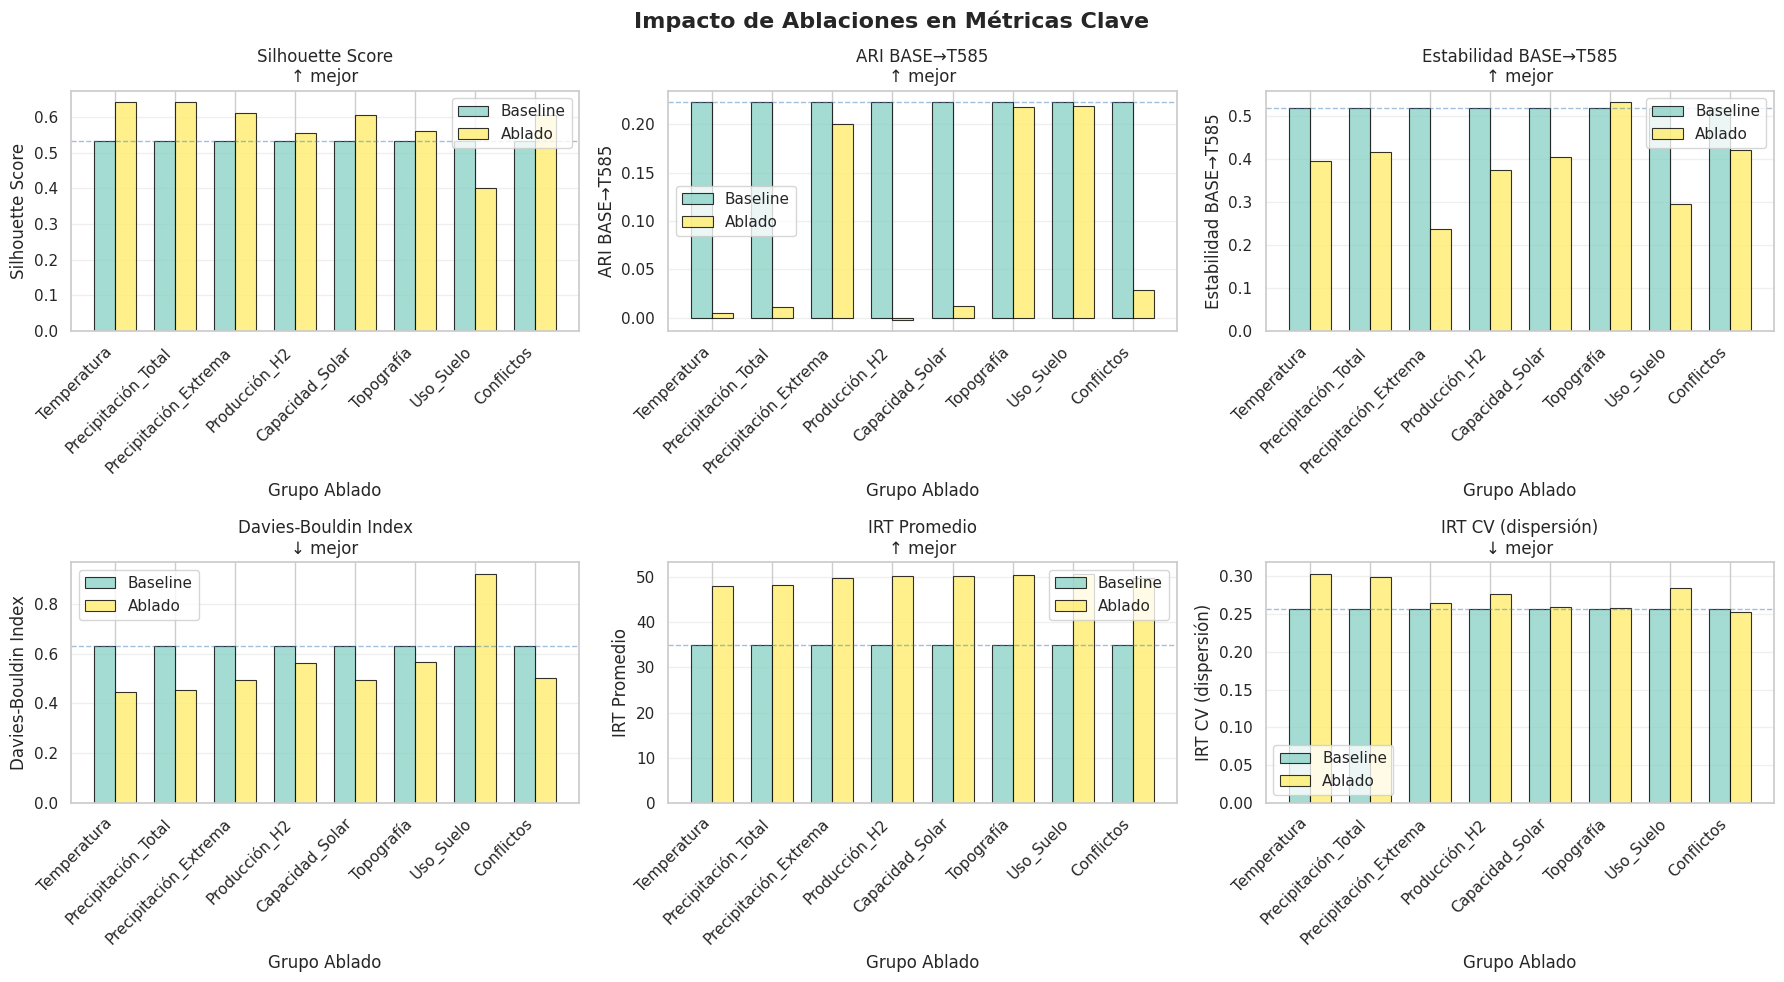

In [15]:
# Gráfico 1: Comparación de métricas clave por grupo
if len(df_ablation) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Impacto de Ablaciones en Métricas Clave', fontsize=16, fontweight='bold')
    
    # Paleta de colores pastel (Set3) para las barras
    colors_palette = plt.cm.Set3(np.linspace(0, 1, 2))  # Para Baseline y Ablado
    
    metrics_to_plot = [
        ('Silhouette', 'Silhouette Score', 'higher_better'),
        ('ARI_T585', 'ARI BASE→T585', 'higher_better'),
        ('Avg_Stability_T585', 'Estabilidad BASE→T585', 'higher_better'),
        ('Davies_Bouldin', 'Davies-Bouldin Index', 'lower_better'),
        ('IRT_Mean', 'IRT Promedio', 'higher_better'),
        ('IRT_CV', 'IRT CV (dispersión)', 'lower_better')
    ]
    
    for idx, (metric, title, direction) in enumerate(metrics_to_plot):
        ax = axes[idx // 3, idx % 3]
        
        if metric in df_ablation.columns and f"{metric}_Abl" in df_ablation.columns:
            groups = df_ablation['Group'].values
            baseline_vals = df_ablation[metric].values
            ablation_vals = df_ablation[f"{metric}_Abl"].values
            
            x = np.arange(len(groups))
            width = 0.35
            
            bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline', 
                          alpha=0.8, color=colors_palette[0], edgecolor='black', linewidth=0.8)
            bars2 = ax.bar(x + width/2, ablation_vals, width, label='Ablado', 
                          alpha=0.8, color=colors_palette[1], edgecolor='black', linewidth=0.8)
            
            ax.set_xlabel('Grupo Ablado')
            ax.set_ylabel(title)
            ax.set_title(f'{title}\n{"↑ mejor" if direction == "higher_better" else "↓ mejor"}')
            ax.set_xticks(x)
            ax.set_xticklabels(groups, rotation=45, ha='right')
            ax.legend()
            ax.grid(axis='y', alpha=0.3)
            
            # Añadir línea horizontal de baseline
            baseline_mean = baseline_vals[0]  # Todas las baseline son iguales
            ax.axhline(y=baseline_mean, color='steelblue', linestyle='--', alpha=0.5, linewidth=1)
    
    plt.tight_layout()
    output_fig1 = os.path.join(PLOTS_DIR, f"ablation_metrics_comparison_{pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')}.png")
    plt.savefig(output_fig1, dpi=300, bbox_inches='tight')
    print(f"Gráfico guardado: {output_fig1}")
    plt.show()
else:
    print("No hay datos para graficar")

Heatmap guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/clustering_k_fold_validation/ablation_heatmap_20251222_191825.png


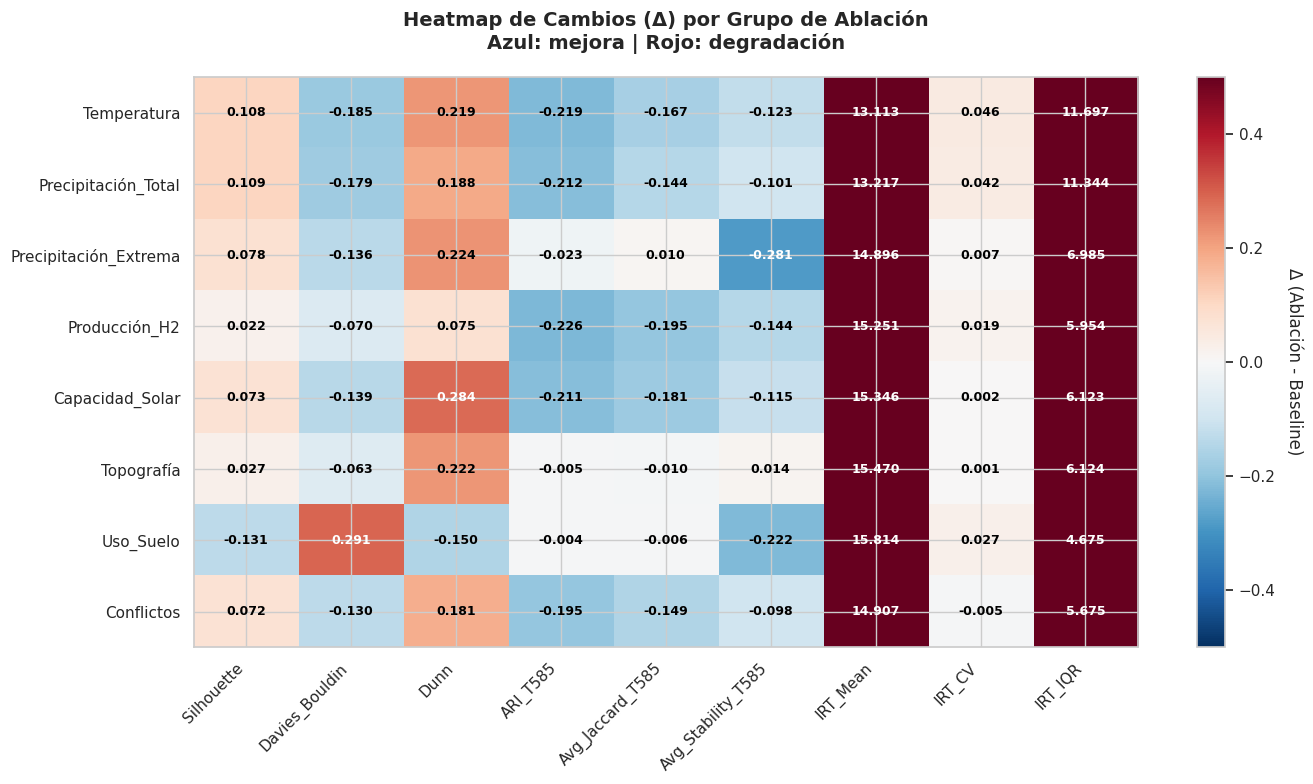

In [16]:
# Gráfico 2: Heatmap de deltas
if len(df_ablation) > 0:
    delta_cols_for_heatmap = [
        'ΔSilhouette', 'ΔDavies_Bouldin', 'ΔDunn',
        'ΔARI_T585', 'ΔAvg_Jaccard_T585', 'ΔAvg_Stability_T585',
        'ΔIRT_Mean', 'ΔIRT_CV', 'ΔIRT_IQR'
    ]
    
    existing_delta_cols = [col for col in delta_cols_for_heatmap if col in df_ablation.columns]
    
    if len(existing_delta_cols) > 0:
        fig, ax = plt.subplots(figsize=(14, 8))
        
        # Preparar datos para heatmap
        heatmap_data = df_ablation[['Group'] + existing_delta_cols].copy()
        heatmap_data = heatmap_data.set_index('Group')
        
        # Crear heatmap
        im = ax.imshow(heatmap_data.values, cmap='RdBu_r', aspect='auto', vmin=-0.5, vmax=0.5)
        
        # Configurar ejes
        ax.set_xticks(np.arange(len(existing_delta_cols)))
        ax.set_yticks(np.arange(len(heatmap_data)))
        ax.set_xticklabels([col.replace('Δ', '') for col in existing_delta_cols], rotation=45, ha='right')
        ax.set_yticklabels(heatmap_data.index)
        
        # Añadir valores en celdas
        for i in range(len(heatmap_data)):
            for j in range(len(existing_delta_cols)):
                val = heatmap_data.values[i, j]
                color = 'white' if abs(val) > 0.25 else 'black'
                ax.text(j, i, f'{val:.3f}', ha='center', va='center', 
                       color=color, fontsize=9, fontweight='bold')
        
        # Título y colorbar
        ax.set_title('Heatmap de Cambios (Δ) por Grupo de Ablación\n'
                    'Azul: mejora | Rojo: degradación', 
                    fontsize=14, fontweight='bold', pad=20)
        
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('Δ (Ablación - Baseline)', rotation=270, labelpad=20)
        
        plt.tight_layout()
        output_fig2 = os.path.join(PLOTS_DIR, f"ablation_heatmap_{pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')}.png")
        plt.savefig(output_fig2, dpi=300, bbox_inches='tight')
        print(f"Heatmap guardado: {output_fig2}")
        plt.show()
    else:
        print("No hay columnas delta para crear heatmap")
else:
    print("No hay datos para graficar")

Ranking guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/clustering_k_fold_validation/ablation_ranking_20251222_191826.png


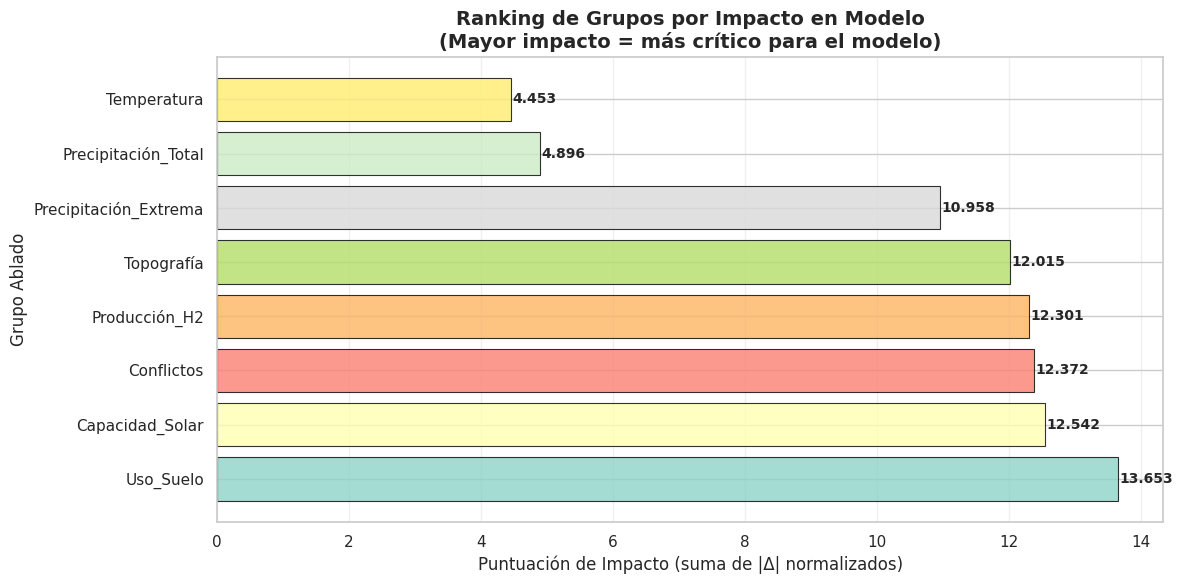

In [17]:
# Gráfico 3: Ranking de impacto
if len(df_ablation) > 0 and 'Impact_Score' in df_summary.columns:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    groups_sorted = df_summary['Group'].values
    impact_sorted = df_summary['Impact_Score'].values
    
    # Paleta de colores pastel (Set3) para los grupos
    colors_palette = plt.cm.Set3(np.linspace(0, 1, len(groups_sorted)))
    
    bars = ax.barh(groups_sorted, impact_sorted, color=colors_palette, alpha=0.8, edgecolor='black', linewidth=0.8)
    
    ax.set_xlabel('Puntuación de Impacto (suma de |Δ| normalizados)', fontsize=12)
    ax.set_ylabel('Grupo Ablado', fontsize=12)
    ax.set_title('Ranking de Grupos por Impacto en Modelo\n(Mayor impacto = más crítico para el modelo)', 
                fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Añadir valores
    for i, (bar, val) in enumerate(zip(bars, impact_sorted)):
        ax.text(val + 0.02, bar.get_y() + bar.get_height()/2, 
               f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    output_fig3 = os.path.join(PLOTS_DIR, f"ablation_ranking_{pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')}.png")
    plt.savefig(output_fig3, dpi=300, bbox_inches='tight')
    print(f"Ranking guardado: {output_fig3}")
    plt.show()
else:
    print("No hay datos de impacto para graficar")

## 9. Análisis Cualitativo por Grupo

Interpretación de resultados para cada grupo de variables ablado.

In [18]:
print("ANÁLISIS CUALITATIVO: INTERPRETACIÓN POR GRUPO DE ABLACIÓN")
print("="*80)
print()

# Definir umbrales de impacto
THRESHOLD_CRITICAL = 0.15  # Cambio > 15% en métricas clave
THRESHOLD_MODERATE = 0.05  # Cambio 5-15%
THRESHOLD_LOW = 0.02       # Cambio < 5%

# Función auxiliar para clasificar impacto
def classify_impact(delta_value, metric_name, baseline_value):
    """Clasifica el impacto de un delta relativo al baseline."""
    relative_change = abs(delta_value) / abs(baseline_value) if baseline_value != 0 else 0
    
    if relative_change > THRESHOLD_CRITICAL:
        return "CRÍTICO"
    elif relative_change > THRESHOLD_MODERATE:
        return "MODERADO"
    elif relative_change > THRESHOLD_LOW:
        return "BAJO"
    else:
        return "MÍNIMO"

# Analizar cada grupo
if len(df_ablation) > 0:
    for idx, row in df_ablation.iterrows():
        group_name = row['Group']
        n_features = row['N_Features_Removed']
        
        print(f"\n{'='*80}")
        print(f"GRUPO: {group_name}")
        print(f"{'='*80}")
        print(f"Features eliminadas: {n_features}")
        print()
        
        # Evaluar impacto en clustering
        print("1. IMPACTO EN CLUSTERING (BASE):")
        print()
        
        silhouette_impact = classify_impact(
            row['ΔSilhouette'], 'Silhouette', row['Silhouette']
        )
        db_impact = classify_impact(
            row['ΔDavies_Bouldin'], 'Davies_Bouldin', row['Davies_Bouldin']
        )
        
        print(f"  • Silhouette: {row['Silhouette']:.4f} → {row['Silhouette_Abl']:.4f} "
              f"(Δ={row['ΔSilhouette']:+.4f}) [{silhouette_impact}]")
        print(f"  • Davies-Bouldin: {row['Davies_Bouldin']:.4f} → {row['Davies_Bouldin_Abl']:.4f} "
              f"(Δ={row['ΔDavies_Bouldin']:+.4f}) [{db_impact}]")
        
        if row['ΔSilhouette'] < -0.05:
            print(f"    ⚠ La eliminación de {group_name} degrada significativamente la separación de clusters")
        elif row['ΔSilhouette'] > 0.02:
            print(f"    ✓ Eliminación mejora ligeramente la calidad de clustering (posible ruido)")
        else:
            print(f"    → Impacto marginal en la estructura de clustering")
        print()
        
        # Evaluar impacto en estabilidad
        print("2. IMPACTO EN ESTABILIDAD BASE → T585:")
        print()
        
        ari_impact = classify_impact(
            row['ΔARI_T585'], 'ARI_T585', row['ARI_T585']
        )
        stability_impact = classify_impact(
            row['ΔAvg_Stability_T585'], 'Avg_Stability_T585', row['Avg_Stability_T585']
        )
        
        print(f"  • ARI: {row['ARI_T585']:.4f} → {row['ARI_T585_Abl']:.4f} "
              f"(Δ={row['ΔARI_T585']:+.4f}) [{ari_impact}]")
        print(f"  • Estabilidad: {row['Avg_Stability_T585']:.4f} → {row['Avg_Stability_T585_Abl']:.4f} "
              f"(Δ={row['ΔAvg_Stability_T585']:+.4f}) [{stability_impact}]")
        print(f"  • Drift: {row['Avg_Drift_T585']:.4f} → {row['Avg_Drift_T585_Abl']:.4f} "
              f"(Δ={row['ΔAvg_Drift_T585']:+.4f})")
        
        if row['ΔARI_T585'] < -0.10:
            print(f"    ⚠ La eliminación de {group_name} reduce fuertemente la consistencia temporal")
        elif row['ΔAvg_Stability_T585'] < -0.10:
            print(f"    ⚠ Pérdida significativa de estabilidad de asignaciones entre escenarios")
        else:
            print(f"    → Estabilidad temporal se mantiene relativamente estable")
        print()
        
        # Evaluar impacto en IRT
        print("3. IMPACTO EN ÍNDICE DE RESILIENCIA TERRITORIAL (IRT):")
        print()
        
        irt_mean_impact = classify_impact(
            row['ΔIRT_Mean'], 'IRT_Mean', row['IRT_Mean']
        )
        irt_cv_impact = classify_impact(
            row['ΔIRT_CV'], 'IRT_CV', row['IRT_CV']
        )
        
        print(f"  • IRT Promedio: {row['IRT_Mean']:.4f} → {row['IRT_Mean_Abl']:.4f} "
              f"(Δ={row['ΔIRT_Mean']:+.4f}) [{irt_mean_impact}]")
        print(f"  • IRT CV: {row['IRT_CV']:.4f} → {row['IRT_CV_Abl']:.4f} "
              f"(Δ={row['ΔIRT_CV']:+.4f}) [{irt_cv_impact}]")
        print(f"  • IRT IQR: {row['IRT_IQR']:.4f} → {row['IRT_IQR_Abl']:.4f} "
              f"(Δ={row['ΔIRT_IQR']:+.4f})")
        
        if abs(row['ΔIRT_Mean']) > 0.10:
            print(f"    ⚠ Cambio sustancial en el nivel de resiliencia territorial")
        if row['ΔIRT_CV'] > 0.15:
            print(f"    ⚠ Aumento significativo de heterogeneidad espacial del IRT")
        elif row['ΔIRT_CV'] < -0.10:
            print(f"    → Reducción de dispersión (distribución más homogénea)")
        print()
        
        # Conclusión integrada
        print("4. CONCLUSIÓN:")
        print()
        
        # Calcular score de criticidad
        criticality_score = (
            abs(row['ΔSilhouette']) * 2.0 +
            abs(row['ΔARI_T585']) * 2.0 +
            abs(row['ΔAvg_Stability_T585']) * 1.5 +
            abs(row['ΔIRT_Mean']) * 2.5 +
            abs(row['ΔIRT_CV']) * 1.0
        )
        
        if criticality_score > 0.5:
            classification = "GRUPO IMPRESCINDIBLE"
            icon = "🔴"
            recommendation = (
                f"La eliminación de {group_name} causa degradación significativa en múltiples "
                f"dimensiones del modelo. Este grupo es CRÍTICO para mantener la calidad del "
                f"clustering, la estabilidad temporal y la interpretabilidad del IRT."
            )
        elif criticality_score > 0.25:
            classification = "GRUPO RELEVANTE"
            icon = "🟡"
            recommendation = (
                f"El grupo {group_name} contribuye de manera importante al modelo. Su eliminación "
                f"produce cambios moderados pero no catastróficos. Se recomienda mantenerlo para "
                f"preservar la robustez del análisis."
            )
        else:
            classification = "GRUPO SECUNDARIO"
            icon = "🟢"
            recommendation = (
                f"El grupo {group_name} tiene impacto limitado en las métricas globales. "
                f"Podría considerarse su simplificación o eliminación si se requiere reducir "
                f"la dimensionalidad del modelo, aunque se recomienda análisis adicional."
            )
        
        print(f"  {icon} {classification}")
        print(f"  Puntuación de criticidad: {criticality_score:.3f}")
        print()
        print(f"  {recommendation}")
        print()
        
        # Coherencia con intuición física/climática
        print("5. COHERENCIA CON INTUICIÓN CLIMÁTICA/ENERGÉTICA:")
        print()
        
        # Interpretaciones específicas por grupo
        interpretations = {
            'Temperatura': (
                "La temperatura es un driver fundamental del clima y afecta directamente "
                "la producción energética solar y la demanda de hidrógeno. Su impacto en el "
                "modelo refleja su rol como variable estructurante del sistema energético-climático."
            ),
            'Precipitación_Total': (
                "La precipitación total y frecuencia de eventos moderados (>10mm) capturan "
                "la disponibilidad hídrica regional, relevante para conflictos por agua y "
                "restricciones operacionales. Su contribución al modelo es coherente con "
                "la gestión de recursos hídricos en zonas semiáridas."
            ),
            'Precipitación_Extrema': (
                "Los eventos extremos de precipitación (rx1day) son indicadores de exposición "
                "a riesgos hidrometeorológicos. Su rol en el modelo refleja la capacidad del "
                "territorio para enfrentar perturbaciones intensas."
            ),
            'Producción_H2': (
                "La producción de hidrógeno es la variable objetivo del sistema energético. "
                "Su impacto en el modelo indica la interconexión entre capacidad productiva "
                "y resiliencia territorial bajo distintos escenarios climáticos."
            ),
            'Capacidad_Solar': (
                "La capacidad solar (CF) y dimensionamiento de electrolizadores determinan "
                "el potencial de producción de H₂ verde. Su contribución al modelo vincula "
                "infraestructura energética con análisis de resiliencia."
            ),
            'Topografía': (
                "Pendiente y elevación condicionan la aptitud para instalación solar y "
                "accesibilidad territorial. Su impacto refleja restricciones geofísicas "
                "para el desarrollo de infraestructura energética."
            ),
            'Uso_Suelo': (
                "Las categorías de uso de suelo (agricultura, urbano, agua/glaciares, etc.) "
                "capturan conflictos potenciales por territorio y restricciones de localización. "
                "Su rol en el modelo representa la dimensión socioambiental de la resiliencia."
            ),
            'Conflictos': (
                "La densidad y proximidad a conflictos socioambientales reflejan tensiones "
                "históricas por recursos. Su contribución al IRT integra la dimensión social "
                "de la resiliencia territorial."
            )
        }
        
        if group_name in interpretations:
            print(f"  {interpretations[group_name]}")
        else:
            print(f"  (Interpretación específica no disponible para {group_name})")
        print()

    print("="*80)
    print()
else:
    print("No hay datos para analizar")
    print()

ANÁLISIS CUALITATIVO: INTERPRETACIÓN POR GRUPO DE ABLACIÓN


GRUPO: Temperatura
Features eliminadas: 6

1. IMPACTO EN CLUSTERING (BASE):

  • Silhouette: 0.5326 → 0.6409 (Δ=+0.1083) [CRÍTICO]
  • Davies-Bouldin: 0.6318 → 0.4468 (Δ=-0.1850) [CRÍTICO]
    ✓ Eliminación mejora ligeramente la calidad de clustering (posible ruido)

2. IMPACTO EN ESTABILIDAD BASE → T585:

  • ARI: 0.2235 → 0.0045 (Δ=-0.2190) [CRÍTICO]
  • Estabilidad: 0.5189 → 0.3964 (Δ=-0.1225) [CRÍTICO]
  • Drift: 2.4258 → 0.3640 (Δ=-2.0618)
    ⚠ La eliminación de Temperatura reduce fuertemente la consistencia temporal

3. IMPACTO EN ÍNDICE DE RESILIENCIA TERRITORIAL (IRT):

  • IRT Promedio: 35.0242 → 48.1375 (Δ=+13.1133) [CRÍTICO]
  • IRT CV: 0.2574 → 0.3038 (Δ=+0.0464) [CRÍTICO]
  • IRT IQR: 13.5575 → 25.2546 (Δ=+11.6971)
    ⚠ Cambio sustancial en el nivel de resiliencia territorial

4. CONCLUSIÓN:

  🔴 GRUPO IMPRESCINDIBLE
  Puntuación de criticidad: 33.668

  La eliminación de Temperatura causa degradación significa

## 10. Consideraciones Finales

Temperatura

Quitarla mejora mucho el clustering BASE pero rompe casi por completo la estabilidad BASE→T585 y cambia fuertemente el nivel y dispersión del IRT.

la temperatura es un driver climático estructural. Hace más “difusos” los clusters estáticos, pero es esencial para capturar cómo cambia el territorio con el calentamiento y para que el IRT tenga sentido físico.

Precipitación_Total

Afecta moderadamente el clustering, muy fuerte la estabilidad entre escenarios y casi nada el IRT.

la precipitación total y la frecuencia de lluvia moderada aportan señal de cambio climático y disponibilidad hídrica, pero no cambian tanto la jerarquía de resiliencia (IRT_mean). Son más bien un componente de estabilidad climática.

Precipitación_Extrema

Igual que temperatura y capacidad solar: mejora el clustering si la sacas, pero derriba ARI/estabilidad y sube el IRT y su IQR.

los extremos (rx1day) son clave para que el índice capture exposición a eventos extremos. Sin ellos, el territorio parece más resiliente de lo que realmente es.

Producción_H₂

Casi no afecta el clustering BASE, pero la estabilidad BASE→T585 se desploma, y el IRT se vuelve más concentrado y con menor IQR.

la producción de H₂ no “arma” los clusters, pero actúa como puente entre clima y sistema energético y ancla el IRT a la realidad productiva. Sin este bloque, el índice pierde conexión con la capacidad real de producir H₂ a futuro.

Capacidad_Solar

Es uno de los grupos con mayor impacto total:

Si se quitas, el clustering BASE se ve precioso (↑Silhouette, ↓DB),

Pero la estabilidad temporal cae brutalmente y el IRT cambia mucho (↑mean, ↑CV, ↑IQR).

la capacidad solar es un driver de vulnerabilidad/heterogeneidad: mete complejidad espacial y temporal, pero precisamente porque está codificando dónde realmente hay potencial fotovoltaico y dónde no. Es uno de los bloques más críticos del modelo.

Topografía

Quitar topografía empeora un poco el clustering BASE (↓Silhouette, ↑DB),

Pero los efectos en estabilidad y en IRT son relativamente pequeños.

la topografía actúa como modulador geomorfológico (refina la forma de los clusters), pero no es el corazón de la resiliencia en el índice.
→ Se puede etiquetar como grupo secundario/moderado: aporta, pero no es central.

Uso_Suelo

Impacto moderado en clustering, fuerte caída en ARI y cambios moderados en IRT_mean (sube cuando se quita).

uso de suelo funciona como restricción socio-territorial. Cuando se quita, el territorio parece más resiliente (IRT sube), porque dejas de penalizar zonas agrícolas, urbanas o de agua. Es un bloque que representa factibilidad y conflicto por espacio más que clima.

Conflictos

Igual patrón que extremos y solar:

Quitarlos mejora bastante el clustering BASE,

Pero destruye estabilidad y eleva el IRT (el territorio se ve “más resiliente” sin conflictos).

conflictos es un bloque netamente social/político que baja el IRT en zonas con mayor tensión. Sin este bloque, el índice se vuelve más optimista pero menos realista. Es crítico para que el IRT incorpore la dimensión de conflictos socioambientales.